In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rdf, msd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import collections
from MDAnalysis.lib.distances import distance_array
plt.style.use("default")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load data
u = mda.Universe(
    "system2000.data",
    "2000_2ns.lammpstrj.gz",
    topology_format="DATA",
    format="LAMMPSDUMP"
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [3]:
#set timestep
timestep_fs = 1.0
dump_stride = 100
dt_ps = timestep_fs * dump_stride / 1000.0  # 1 ps per frame

In [4]:
#check time for frame
frame_idx = 10
frame_time = u.trajectory[frame_idx].frame * dt_ps
print(frame_time)  # 1 ps

1.0


In [5]:
print(u)
print(u.atoms.n_atoms)
print(len(u.trajectory))

<Universe with 17000 atoms>
17000
2000


In [6]:
print(u.atoms.types[:10])
print(u.atoms.positions[:5])

['4' '7' '2' '3' '3' '1' '3' '7' '4' '2']
[[26.172544   4.985836  22.044544 ]
 [26.992605   5.0042343 21.536224 ]
 [26.885904   3.9372346 20.638895 ]
 [25.97715    3.9526346 20.017506 ]
 [26.880037   2.9869344 21.194836 ]]


In [7]:
Ow = u.select_atoms("type 6")
Hw = u.select_atoms("type 5")
Og = u.select_atoms("type 7")
Hg = u.select_atoms("type 4")

In [8]:
#Radial Distribution Function - water oxygens
rdf_OwOw = rdf.InterRDF(Ow, Ow, range=(0, 10), nbins=200)
rdf_OwOw.run()

#3h 14m on PC
#58m 58s on M5

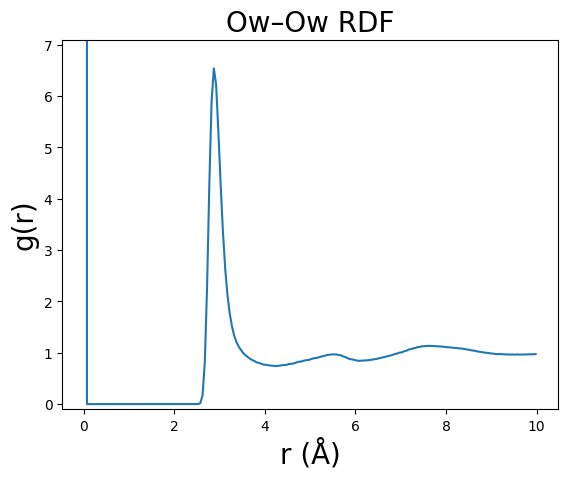

In [9]:
plt.plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Ow–Ow RDF", fontsize=20)
plt.ylim(-0.1, 7.1)
plt.savefig("figures/2ns/OwOw-rdf.png", format="png", )
plt.show()

In [10]:
#Radial Distribution Function - glycerol oxygens
rdf_OgOg = rdf.InterRDF(Og, Og, range=(0, 10), nbins=200)
rdf_OgOg.run()

#3h 21m on PC
#1h 6m on M5

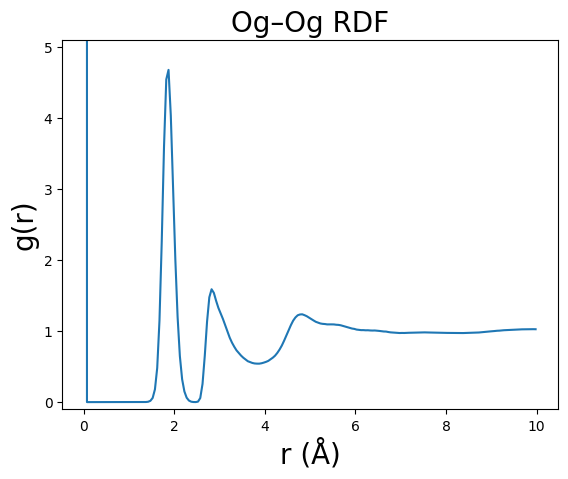

In [91]:
plt.plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Og–Og RDF", fontsize=20)
plt.ylim(-0.1, 5.1)
plt.savefig("figures/2ns/OgOg-rdf.png", format="png", )
plt.show()

In [12]:
#Radial Distribution Function - water to glycerol oxygens
rdf_OwOg = rdf.InterRDF(Ow, Og, range=(0, 10), nbins=200)
rdf_OwOg.run()

#3h 17m on PC
#1h 5m on M5

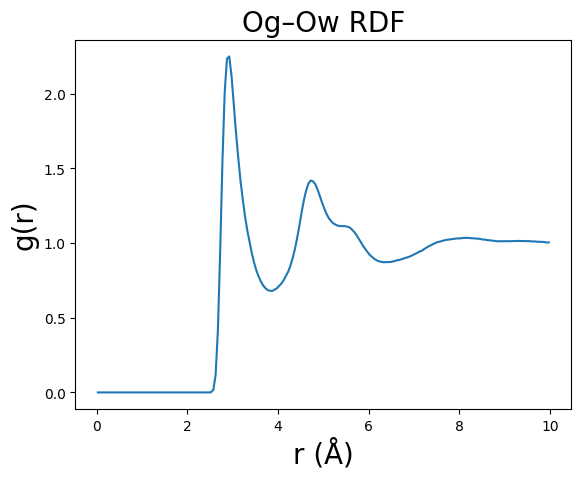

In [15]:
plt.plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Og–Ow RDF", fontsize=20)
plt.savefig("figures/2ns/OgOw-rdf.png", format="png", )
plt.show()

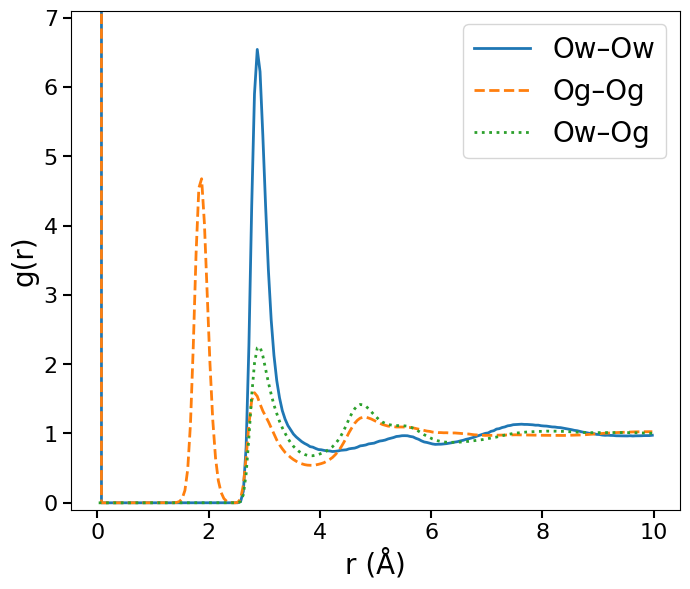

In [16]:
fig, ax = plt.subplots(figsize=(7,6))

ax.plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf,
        label="Ow–Ow", linewidth=2)

ax.plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf,
        label="Og–Og", linestyle="--", linewidth=2)

ax.plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf,
        label="Ow–Og", linestyle=":", linewidth=2)

ax.set_xlabel("r (Å)", fontsize=20)
ax.set_ylabel("g(r)", fontsize=20)
ax.set_ylim(-0.1, 7.1)
ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)
ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig("figures/2ns/rdf-all-combined.png", format="png")
plt.show()

In [17]:
#Coordination Numbers
def coordination_number(r, g_r, rho, r_cut):
    mask = r <= r_cut
    integrand = 4 * np.pi * rho * g_r[mask] * r[mask]**2
    return np.trapezoid(integrand, r[mask])

In [18]:
# number density of oxygens
rho_Ow = Ow.n_atoms / np.prod(u.dimensions[:3])
rho_Og = Og.n_atoms / np.prod(u.dimensions[:3])

# find first minimum manually (example value!)
r_cut = 3.4  # Å

#Coordination number for water oxygens
CN_OwOw = coordination_number(
    rdf_OwOw.results.bins,
    rdf_OwOw.results.rdf,
    rho_Ow,
    r_cut
)

#Coordination number for glycerol oxygens
CN_OgOg = coordination_number(
    rdf_OgOg.results.bins,
    rdf_OgOg.results.rdf,
    rho_Og,
    r_cut
)

#Coordination number for glycerol oxygens to water oxygens
CN_OwOg = coordination_number(
    rdf_OwOg.results.bins,
    rdf_OwOg.results.rdf,
    rho_Og,
    r_cut
)

#Coordination number for water oxygens to glycerol oxygens
CN_OgOw = coordination_number(
    rdf_OwOg.results.bins,
    rdf_OwOg.results.rdf,
    rho_Ow,
    r_cut
)

print("Ow–Ow coordination number:", CN_OwOw)
print("Og-Og coordination number:", CN_OgOg)
print("Ow-Og coordination number:", CN_OwOg)
print("Og-Ow coordination number:", CN_OgOw)

Ow–Ow coordination number: 2.2827657117623263
Og-Og coordination number: 3.692271175408571
Ow-Og coordination number: 2.684183618583253
Og-Ow coordination number: 0.8947278225165457


In [19]:
def coordination_curve(r, g_r, rho):
    integrand = 4 * np.pi * rho * g_r * r**2
    dr = np.diff(r)
    dr = np.append(dr, dr[-1])
    return np.cumsum(integrand * dr)

In [20]:
r_owow = rdf_OwOw.results.bins
r_ogog = rdf_OgOg.results.bins
r_owog = rdf_OwOg.results.bins

cn_curve_OwOw = coordination_curve(r_owow, rdf_OwOw.results.rdf, rho_Ow)
cn_curve_OgOg = coordination_curve(r_ogog, rdf_OgOg.results.rdf, rho_Og)
cn_curve_OwOg = coordination_curve(r_owog, rdf_OwOg.results.rdf, rho_Og)
cn_curve_OgOw = coordination_curve(r_owog, rdf_OwOg.results.rdf, rho_Ow)

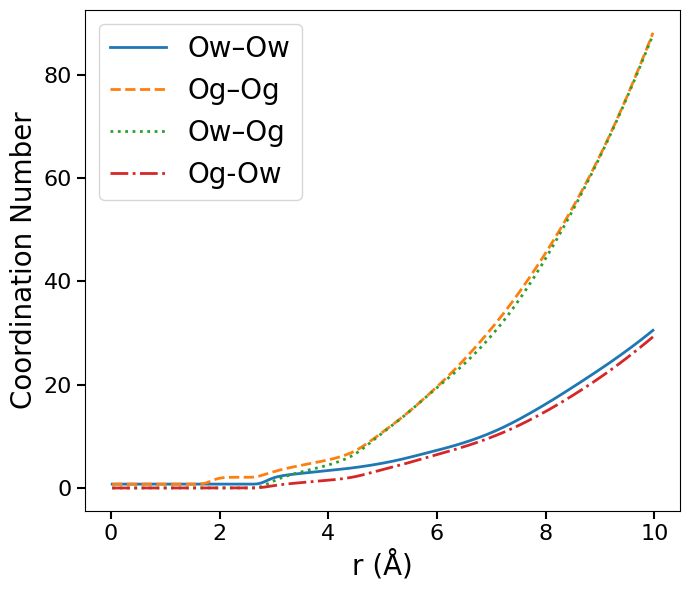

In [57]:
fig, ax = plt.subplots(figsize=(7,6))

ax.plot(r_owow, cn_curve_OwOw, label="Ow–Ow", linewidth=2)
ax.plot(r_ogog, cn_curve_OgOg, label="Og–Og", linestyle="--", linewidth=2)
ax.plot(r_owog, cn_curve_OwOg, label="Ow–Og", linestyle=":", linewidth=2)
ax.plot(r_owog, cn_curve_OgOw, label="Og-Ow", linestyle="-.", linewidth=2)

#ax.set_title("Coordination Curves", fontsize=22)
ax.set_xlabel("r (Å)", fontsize=20)
ax.set_ylabel("Coordination Number", fontsize=20)
ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)
ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig("figures/2ns/coordination-curves.png")
plt.show()

In [22]:
#Coordination Distribution
cutoff = 3.5  # Å

coord_numbers = []

for ts in u.trajectory:
    dists = distance_array(
        Ow.positions,
        Og.positions,
        box=u.dimensions
    )
    counts = np.sum(dists < cutoff, axis=1)
    coord_numbers.extend(counts)

#3m 35s on PC

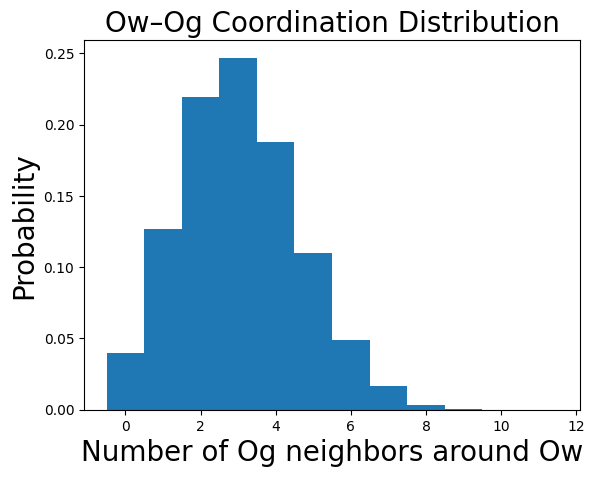

In [23]:
plt.hist(coord_numbers, bins=np.arange(0, max(coord_numbers)+2)-0.5, density=True)
plt.xlabel("Number of Og neighbors around Ow", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.title("Ow–Og Coordination Distribution", fontsize=20)
plt.savefig("figures/2ns/OwOg-Coordination.png", format="png", )
plt.show()

In [24]:
water_residues = []
glycerol_residues = []

for res in u.residues:
    types = set(res.atoms.types)

    if types.issubset({"5", "6"}):        # water (Hw, Ow)
        water_residues.append(res)
    elif types.issubset({"1", "2", "3", "4", "7"}):      # glycerol (Hg, Og)
        glycerol_residues.append(res)

In [25]:
print("Water residues:", len(water_residues))
print("Glycerol residues:", len(glycerol_residues))

print("Atoms per water residue:",
      set(len(res.atoms) for res in water_residues[:10]))
print("Atoms per glycerol residue:",
      set(len(res.atoms) for res in glycerol_residues[:10]))

Water residues: 1000
Glycerol residues: 1000
Atoms per water residue: {3}
Atoms per glycerol residue: {14}


In [29]:
OgA_atoms = []
OgB_atoms = []

for res in glycerol_residues:
    atoms = res.atoms
    OgA_atoms.append(atoms[1])        # center oxygen
    OgB_atoms.extend([atoms[2], atoms[3]])  # two side oxygens

In [30]:
OgA = mda.AtomGroup(OgA_atoms)
OgB = mda.AtomGroup(OgB_atoms)

print("Center oxygens (OgA):", len(OgA))
print("Side oxygens (OgB):", len(OgB))

Center oxygens (OgA): 1000
Side oxygens (OgB): 2000


In [81]:
rdf_OgAOgA = rdf.InterRDF(OgA, OgA, range=(0,10), nbins=200)
rdf_OgAOgA.run()

#58m 39s on M5

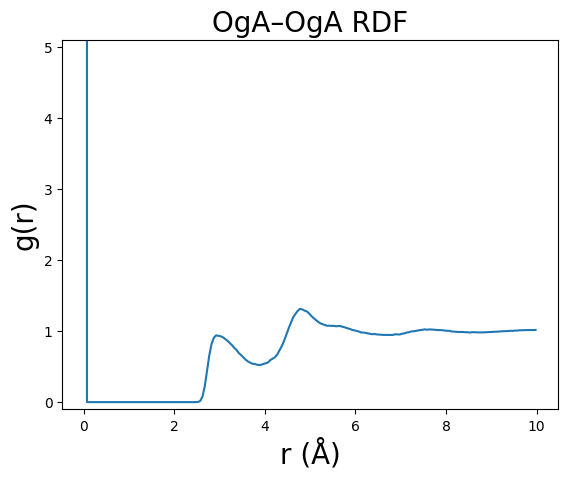

In [84]:
plt.plot(rdf_OgAOgA.results.bins, rdf_OgAOgA.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("OgA–OgA RDF", fontsize=20)
plt.ylim(-0.1, 5.1)
plt.savefig("figures/2ns/OgAOgA-rdf.png", format="png", )
plt.show()

In [120]:
rdf_OgBOgB = rdf.InterRDF(OgB, OgB, range=(0,10), nbins=200)
rdf_OgBOgB.run()

#59m 20s on M5

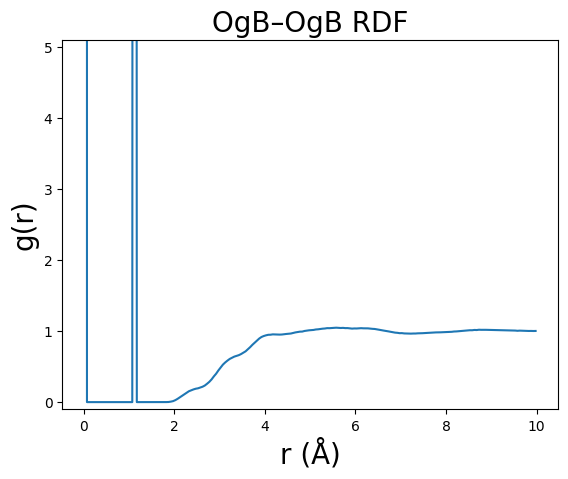

In [121]:
plt.plot(rdf_OgBOgB.results.bins, rdf_OgBOgB.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("OgB–OgB RDF", fontsize=20)
plt.ylim(-0.1, 5.1)
plt.savefig("figures/2ns/OgBOgB-rdf.png", format="png", )
plt.show()

In [32]:
rdf_OwOgA = rdf.InterRDF(Ow, OgA, range=(0,10), nbins=200)
rdf_OwOgA.run()

#58m 56s on M5

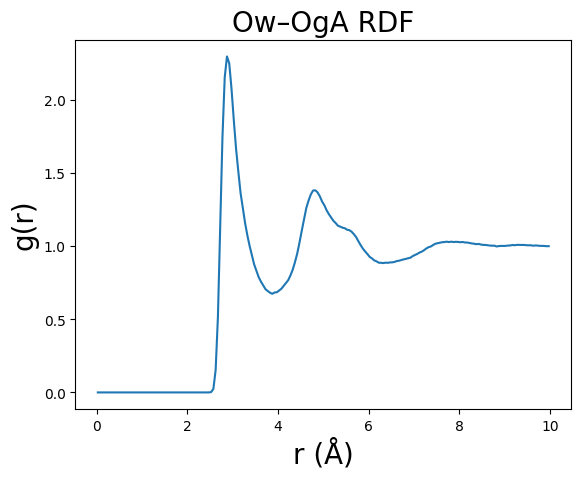

In [90]:
plt.plot(rdf_OwOgA.results.bins, rdf_OwOgA.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Ow–OgA RDF", fontsize=20)
plt.savefig("figures/2ns/OwOgA-rdf.png", format="png", )
plt.show()

In [35]:
rdf_OwOgB = rdf.InterRDF(Ow, OgB, range=(0,10), nbins=200)
rdf_OwOgB.run()

#1h 0m on M5

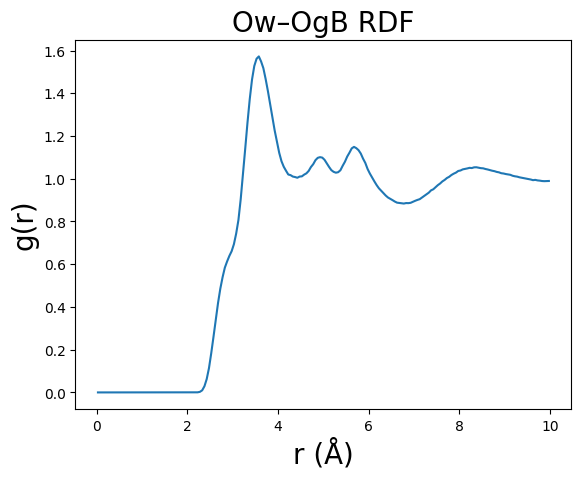

In [89]:
plt.plot(rdf_OwOgB.results.bins, rdf_OwOgB.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Ow–OgB RDF", fontsize=20)
plt.savefig("figures/2ns/OwOgB-rdf.png", format="png", )
plt.show()

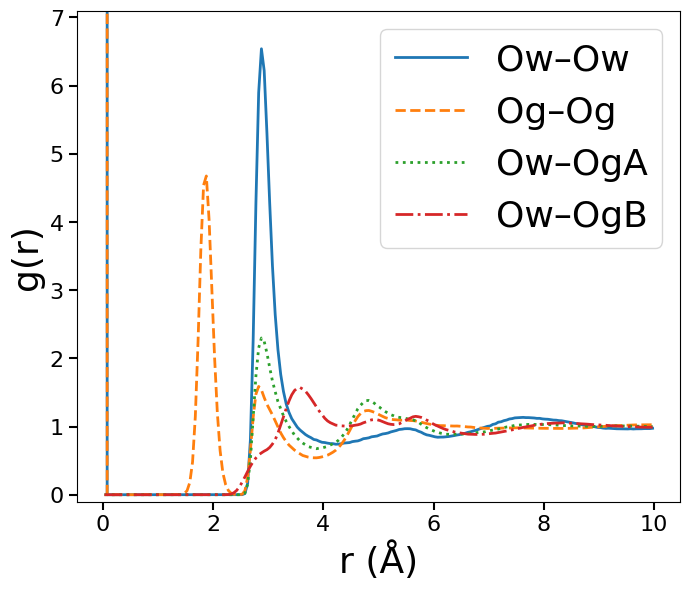

In [115]:
fig, ax = plt.subplots(figsize=(7,6))

ax.plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf,
        label="Ow–Ow", linewidth=2)

ax.plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf,
        linestyle="--", label="Og–Og", linewidth=2)

#ax.plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf, linestyle=(0,(3,1,1,1)), label="Ow–Og", linewidth=2)

ax.plot(rdf_OwOgA.results.bins, rdf_OwOgA.results.rdf,
        linestyle=":", label="Ow–OgA", linewidth=2)

ax.plot(rdf_OwOgB.results.bins, rdf_OwOgB.results.rdf,
        linestyle="-.", label="Ow–OgB", linewidth=2)

ax.set_xlabel("r (Å)", fontsize=26)
ax.set_ylabel("g(r)", fontsize=26)

ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)
ax.set_ylim(-0.1, 7.1)

ax.legend(fontsize=26)

plt.tight_layout()
plt.savefig("figures/2ns/rdf-all-combined-ab.png")
plt.show()

In [41]:
rho_OgA = OgA.n_atoms / np.prod(u.dimensions[:3])
rho_OgB = OgB.n_atoms / np.prod(u.dimensions[:3])

In [45]:
CN_OwOgA = coordination_number(
    rdf_OwOgA.results.bins,
    rdf_OwOgA.results.rdf,
    rho_OgA,
    r_cut
)

CN_OwOgB = coordination_number(
    rdf_OwOgB.results.bins,
    rdf_OwOgB.results.rdf,
    rho_OgB,
    r_cut
)

CN_OgAOw = coordination_number(
    rdf_OwOgA.results.bins,
    rdf_OwOgA.results.rdf,
    rho_Ow,
    r_cut
)

CN_OgBOw = coordination_number(
    rdf_OwOgB.results.bins,
    rdf_OwOgB.results.rdf,
    rho_Ow,
    r_cut
)

print("Ow–OgA coordination number:", CN_OwOgA)
print("Ow–OgB coordination number:", CN_OwOgB)
print("OgA–Ow coordination number:", CN_OgAOw)
print("OgB–Ow coordination number:", CN_OgBOw)

Ow–OgA coordination number: 0.904363290854658
Ow–OgB coordination number: 1.0004572791739552
OgA–Ow coordination number: 0.9045519417790149
OgB–Ow coordination number: 0.5003329876915524


In [52]:
r_owoga = rdf_OwOgA.results.bins
r_owogb = rdf_OwOgB.results.bins

# coordination curves for center oxygen
cn_curve_OwOgA = coordination_curve(r_owoga, rdf_OwOgA.results.rdf, rho_OgA)
cn_curve_OgAOw = coordination_curve(r_owoga, rdf_OwOgA.results.rdf, rho_Ow)

# coordination curves for side oxygens
cn_curve_OwOgB = coordination_curve(r_owogb, rdf_OwOgB.results.rdf, rho_OgB)
cn_curve_OgBOw = coordination_curve(r_owogb, rdf_OwOgB.results.rdf, rho_Ow)

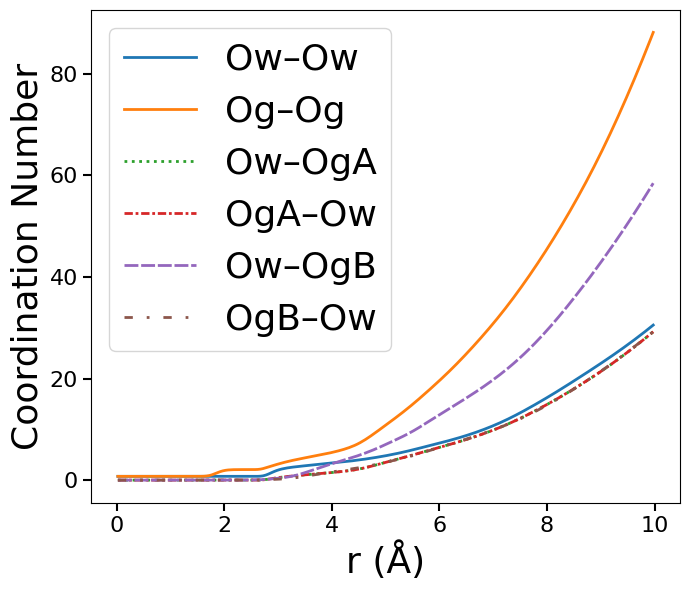

In [118]:
fig, ax = plt.subplots(figsize=(7,6))

# water / glycerol networks
ax.plot(r_owow, cn_curve_OwOw, label="Ow–Ow", linewidth=2)
ax.plot(r_ogog, cn_curve_OgOg, label="Og–Og", linewidth=2)

# total cross interactions
#ax.plot(r_owog, cn_curve_OwOg, label="Ow–Og", linestyle="--", linewidth=2)
#ax.plot(r_owog, cn_curve_OgOw, label="Og–Ow", linestyle="-.", linewidth=2)

# central glycerol oxygen
ax.plot(r_owoga, cn_curve_OwOgA, label="Ow–OgA", linestyle=":", linewidth=2)
ax.plot(r_owoga, cn_curve_OgAOw, label="OgA–Ow", linestyle=(0,(3,1,1,1)), linewidth=2)

# terminal glycerol oxygens
ax.plot(r_owogb, cn_curve_OwOgB, label="Ow–OgB", linestyle=(0,(5,1)), linewidth=2)
ax.plot(r_owogb, cn_curve_OgBOw, label="OgB–Ow", linestyle=(0,(3,5,1,5)), linewidth=2)

ax.set_xlabel("r (Å)", fontsize=26)
ax.set_ylabel("Coordination Number", fontsize=26)

ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)

ax.legend(fontsize=26)

plt.tight_layout()
plt.savefig("figures/2ns/coordination-curves-ab.png")
plt.show()

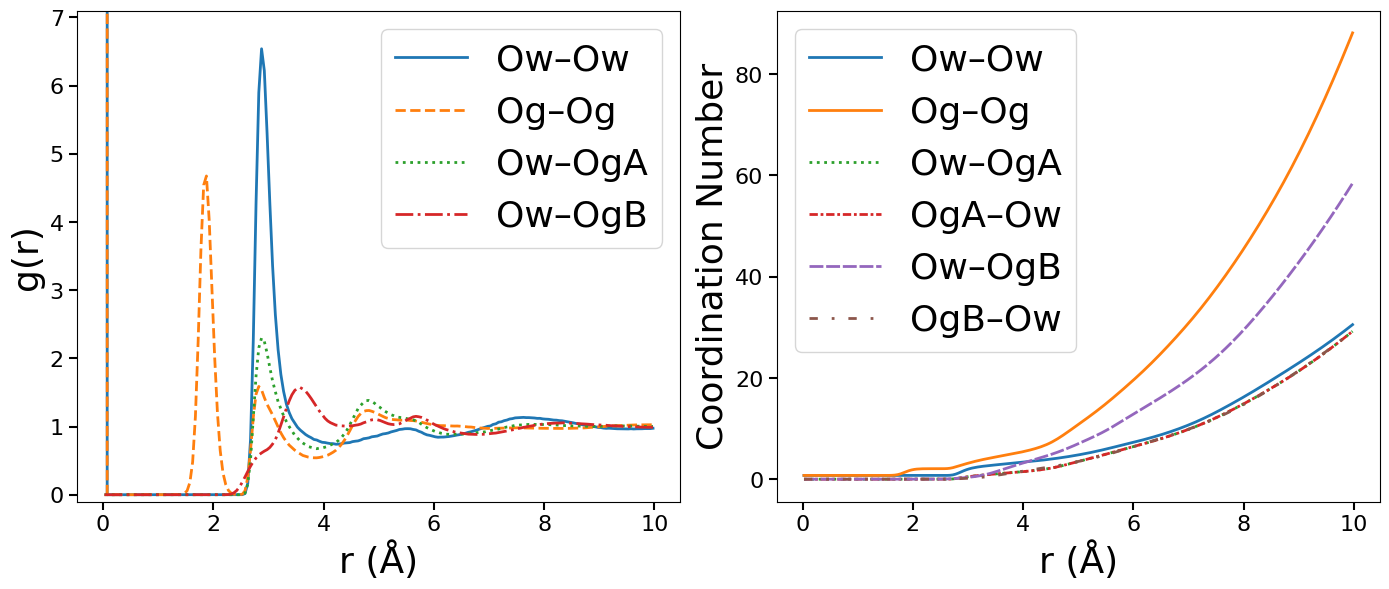

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# RDFs (left panel)
ax = axes[0]

ax.plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf,
        label="Ow–Ow", linewidth=2)

ax.plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf,
        linestyle="--", label="Og–Og", linewidth=2)

ax.plot(rdf_OwOgA.results.bins, rdf_OwOgA.results.rdf,
        linestyle=":", label="Ow–OgA", linewidth=2)

ax.plot(rdf_OwOgB.results.bins, rdf_OwOgB.results.rdf,
        linestyle="-.", label="Ow–OgB", linewidth=2)

ax.set_xlabel("r (Å)", fontsize=26)
ax.set_ylabel("g(r)", fontsize=26)

ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)
ax.set_ylim(-0.1, 7.1)

ax.legend(fontsize=26)

# -------------------

# Coordination curves (right panel)
ax = axes[1]

# water / glycerol networks
ax.plot(r_owow, cn_curve_OwOw, label="Ow–Ow", linewidth=2)
ax.plot(r_ogog, cn_curve_OgOg, label="Og–Og", linewidth=2)

# total cross interactions
#ax.plot(r_owog, cn_curve_OwOg, label="Ow–Og", linestyle="--", linewidth=2)
#ax.plot(r_owog, cn_curve_OgOw, label="Og–Ow", linestyle="-.", linewidth=2)

# central glycerol oxygen
ax.plot(r_owoga, cn_curve_OwOgA, label="Ow–OgA", linestyle=":", linewidth=2)
ax.plot(r_owoga, cn_curve_OgAOw, label="OgA–Ow", linestyle=(0,(3,1,1,1)), linewidth=2)

# terminal glycerol oxygens
ax.plot(r_owogb, cn_curve_OwOgB, label="Ow–OgB", linestyle=(0,(5,1)), linewidth=2)
ax.plot(r_owogb, cn_curve_OgBOw, label="OgB–Ow", linestyle=(0,(3,5,1,5)), linewidth=2)

ax.set_xlabel("r (Å)", fontsize=26)
ax.set_ylabel("Coordination Number", fontsize=26)

ax.tick_params(axis="both", labelsize=16, length=6, width=1.5)

ax.legend(fontsize=26)

plt.tight_layout()
plt.savefig("figures/2ns/rdf_coordination_combined.png")
plt.show()

In [37]:
water_com = np.array([res.atoms.center_of_mass() for res in water_residues])
glycerol_com = np.array([res.atoms.center_of_mass() for res in glycerol_residues])

In [66]:
#MSD and Diffusion
msd_water = msd.EinsteinMSD(u, select="type 6", msd_type="xyz")
msd_water.run()
print(msd_water.results.keys())

#3h 5m on PC

100%|██████████| 1000/1000 [00:00<00:00, 4320.29it/s]

KeysView({'msds_by_particle': array([[ 0.00000000e+00, -1.86264515e-09, -2.32830644e-10, ...,
        -1.86264515e-09, -5.58793545e-09, -3.72529030e-09],
       [ 4.22923339e-01,  4.02770527e-01,  3.54672981e-01, ...,
         3.50976957e-01,  3.92878613e-01,  4.65793021e-01],
       [ 4.44045011e-01,  4.02664965e-01,  3.65177127e-01, ...,
         3.59568647e-01,  4.05905248e-01,  4.79257935e-01],
       ...,
       [ 8.51463678e+00,  2.98386477e+00,  3.22560337e+00, ...,
         1.41019012e+01,  1.15860347e+00,  3.35845625e+00],
       [ 8.86895825e+00,  2.92003601e+00,  4.08101723e+00, ...,
         1.58402664e+01,  5.92528231e-01,  3.89911149e+00],
       [ 7.48770991e+00,  3.73428061e+00,  2.97115011e+00, ...,
         1.85609213e+01,  5.22868768e-02,  4.05018688e+00]],
      shape=(2000, 1000)), 'timeseries': array([-1.92236621e-09,  4.55849043e+01,  4.65955037e+01, ...,
        1.98823831e+02,  1.91976919e+02,  1.97314287e+02], shape=(2000,)), 'delta_t_values': array([0.000e+00

In [67]:
# Mean Squared Displacement (MSD)
msd_vals = msd_water.results.timeseries

# time axis (ps)
time = np.arange(len(msd_vals)) * dt_ps

print(time[:5])
print(time[-1])

[0.  0.1 0.2 0.3 0.4]
199.9


In [68]:
print(type(msd_water.results.timeseries))
print(msd_water.results.timeseries.shape)
print(msd_water.results.timeseries[:10])

<class 'numpy.ndarray'>
(2000,)
[-1.92236621e-09  4.55849043e+01  4.65955037e+01  4.66536800e+01
  4.72211953e+01  4.78166625e+01  4.86553009e+01  4.89246604e+01
  4.90309685e+01  4.95344998e+01]


In [69]:
print("dt_ps =", dt_ps)
print("time[0:5] =", time[:5])
print("time[-1] =", time[-1])

dt_ps = 0.1
time[0:5] = [0.  0.1 0.2 0.3 0.4]
time[-1] = 199.9


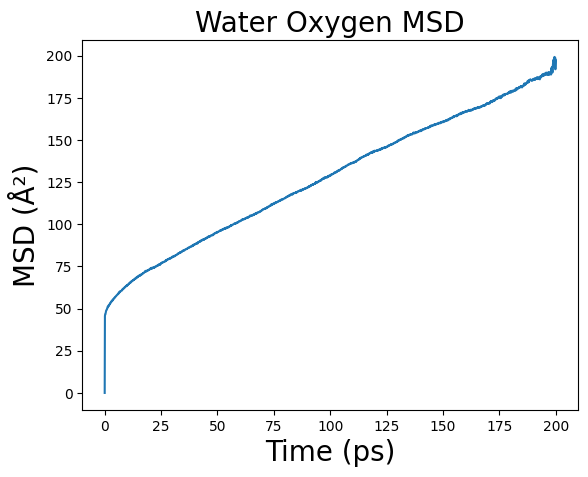

In [70]:
plt.plot(time, msd_vals)
plt.xlabel("Time (ps)", fontsize=20)
plt.ylabel("MSD (Å²)", fontsize=20)
plt.title("Water Oxygen MSD", fontsize=20)
plt.savefig("figures/2ns/Ow-msd.png", format="png", )
plt.show()

In [71]:
fit_start = int(0.7 * len(time))
slope, _ = np.polyfit(time[fit_start:], msd_vals[fit_start:], 1)

D_water = slope / 6.0
print("Water diffusion coefficient (Å²/ps):", D_water)

Water diffusion coefficient (Å²/ps): 0.10308358267396317


In [72]:
n_atoms_per_gly = 7
n_gly = len(Og) // 1

glycerol_groups = [
    u.select_atoms(f"bynum {i}-{i+n_atoms_per_gly-1}")
    for i in range(1, len(u.atoms)+1, n_atoms_per_gly)
]

In [73]:
# Compute COM trajectory
glycerol_com_traj = []
for ts in u.trajectory:
    coms = np.array([grp.center_of_mass() for grp in glycerol_groups])
    glycerol_com_traj.append(coms)

glycerol_com_traj = np.array(glycerol_com_traj)  # shape (T, N_mol, 3)

In [74]:
# Compute MSD
def com_msd(positions):
    r0 = positions[0]
    disp = positions - r0
    return np.mean(np.sum(disp**2, axis=2), axis=1)

msd_gly = com_msd(glycerol_com_traj)
time_gly = np.arange(len(msd_gly)) * dt_ps

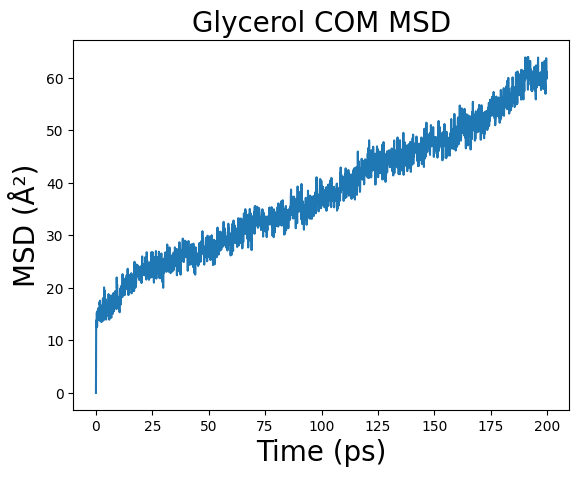

In [75]:
plt.figure()
plt.plot(time_gly, msd_gly)
plt.xlabel("Time (ps)", fontsize=20)
plt.ylabel("MSD (Å²)", fontsize=20)
plt.title("Glycerol COM MSD", fontsize=20)
plt.savefig("figures/2ns/Og-msd.png", format="png", )
plt.show()

In [76]:
fit_start = int(0.2 * len(time_gly))
slope, _ = np.polyfit(time_gly[fit_start:], msd_gly[fit_start:], 1)
D_gly = slope / 6.0
print("Glycerol diffusion coefficient (Å²/ps):", D_gly)

Glycerol diffusion coefficient (Å²/ps): 0.03553500194041525


In [77]:
u.trajectory[0].has_velocities

True